In [33]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process.aggregation import group_samples, add_total_cn
from cns.display.plot import plot_lines, fig_lines, fig_dots,  fig_dots, plot_dots
from cns.data_utils import  main_load_data, get_cns_for_type, load_samples_out, load_merged_samples, load_all_samples, load_COSMIC, save_cns_fig
from cns.utils.conversions import segs_to_df, calc_mid

plt.rcParams.update({'font.size': 12})

In [35]:
tcga_samples = load_samples_out("TCGA_hg19_samples.tsv")
len(tcga_samples[tcga_samples["type"] == 'LUAD']) 

472

In [36]:
samples_df, cns_df = main_load_data("1MB")
datasets = samples_df["source"].unique()

In [37]:
luad_dict = { k : get_cns_for_type(cns_df, samples_df.query(f"source == '{k}'"), "LUAD") for k in datasets }
lusc_dict = { k : get_cns_for_type(cns_df, samples_df.query(f"source == '{k}'"), "LUSC") for k in datasets }
means_single = [add_total_cn(group_samples(dataset)) for dataset in [v for k, v in luad_dict.items()] + [v for k, v in lusc_dict.items()]]
luad_all = pd.concat([v for k, v in luad_dict.items()])
lusc_all = pd.concat([v for k, v in lusc_dict.items()])
means_all = [add_total_cn(group_samples(dataset)) for dataset in [luad_all, lusc_all]]

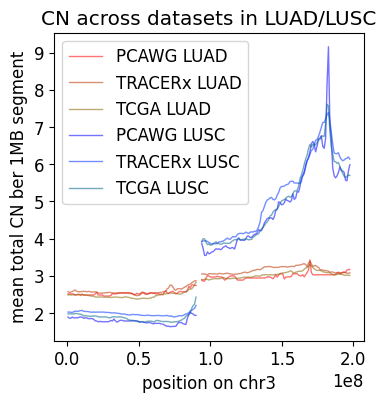

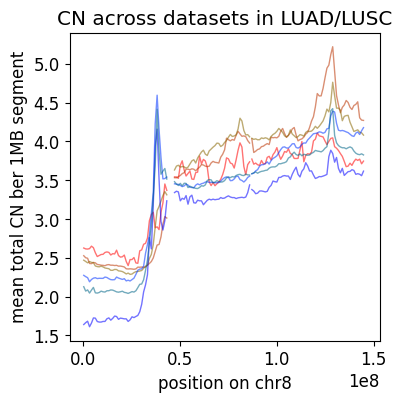

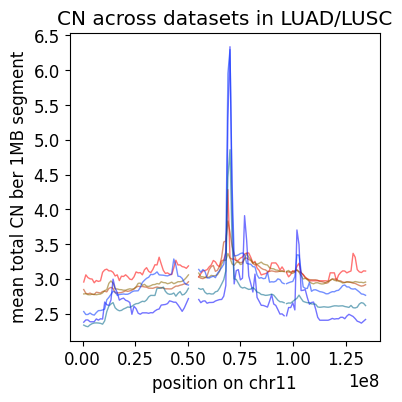

In [38]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
colors = ["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"]
chroms = ["chr3", "chr8", "chr11"]
for chrom in chroms:
	fig, ax = fig_lines(means_single, labels, column="total_cn", color=colors, chrom=chrom)
	ax.set_ylabel("mean total CN ber 1MB segment")
	ax.set_title("CN across datasets in LUAD/LUSC")
	if chrom == "chr3":
		ax.legend(loc='upper left')
	else:
		# disable legend
		ax.legend().set_visible(False)
	save_cns_fig(f"fig_LUAD_LUSC_single_{chrom}")

In [39]:
# pearson correlation of means_single[0]["total_cn"] and means_single[1]["total_cn"]
print("Correlations on 1 Mb segments between datasets")
corr = means_single[3]["total_cn"].corr(means_single[4]["total_cn"], method='pearson')
print("PCAWG-TRACERx", corr)
corr = means_single[3]["total_cn"].corr(means_single[5]["total_cn"], method='pearson')
print("PCAWG-TCGA",corr)
corr = means_single[4]["total_cn"].corr(means_single[5]["total_cn"], method='pearson')
print("TRACERx-TCGA", corr)

Correlations on 1 Mb segments between datasets
PCAWG-TRACERx 0.885116395172436
PCAWG-TCGA 0.9656743086519445
TRACERx-TCGA 0.8926420527143548


In [40]:
_, cosmic_df = main_load_data("COSMIC")
cosmic_group = group_samples(cosmic_df)
cosmic_genes = segs_to_df(load_COSMIC())
cosmic_genes.head()

,chrom,start,end,name
0,chr1,2160133,2241558,SKI
1,chr1,2487077,2496821,TNFRSF14
2,chr1,2985731,3355185,PRDM16
3,chr1,6241328,6269449,RPL22
4,chr1,6845383,7829766,CAMTA1


In [41]:
cosmic_lusc_group = add_total_cn(group_samples(get_cns_for_type(cosmic_df, samples_df, "LUSC")))
cosmic_lusc_group = cosmic_lusc_group.merge(cosmic_genes, on=["chrom", "start", "end"])
cosmic_luad_group = add_total_cn(group_samples(get_cns_for_type(cosmic_df, samples_df, "LUAD")))
cosmic_luad_group = cosmic_luad_group.merge(cosmic_genes, on=["chrom", "start", "end"])

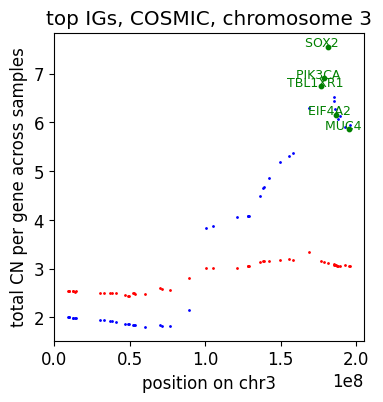

In [42]:
fig, ax = fig_dots(cosmic_lusc_group, chrom="chr3", column="total_cn")
plot_dots(ax, cosmic_luad_group, chrom="chr3", column="total_cn", color="red")
genes = ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]

positions = {
    'EIF4A2': (0, 0),
    'SOX2': (0, 0),
    'TBL1XR1': (0, 0),
    'PIK3CA': (0, 0),
    "MUC4": (0, 0)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in genes:
        mid = calc_mid(row)
        plt.scatter(mid, row['total_cn'], color='green', s=10)
        text = f"{row['name']}"
        x, y = positions[row['name']]
        plt.text(mid + x * 10**8, row['total_cn'] + y, text + "   ", color="green", size=9, ha='center')


ax.set_ylabel("total CN per gene across samples")
plt.title("top IGs, COSMIC, chromosome 3")
save_cns_fig(f"fig_COSMIC_dots_IG_att_chr3")

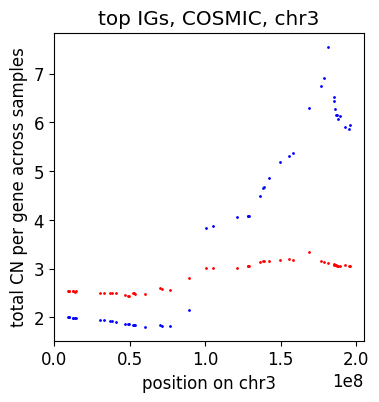

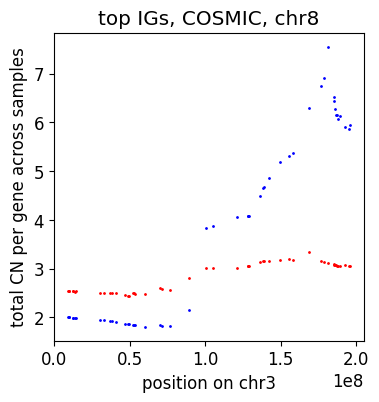

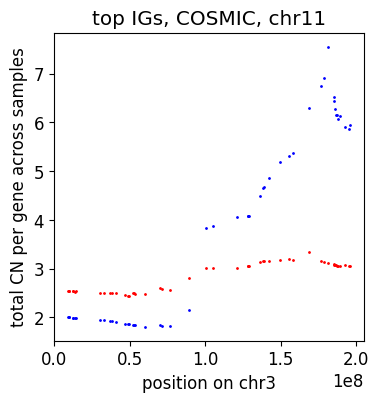

In [43]:
for chrom in chroms:
    fig, ax = fig_dots(cosmic_lusc_group, chrom="chr3", column="total_cn")
    plot_dots(ax, cosmic_luad_group, chrom="chr3", column="total_cn", color="red")

    ax.set_ylabel("total CN per gene across samples")
    plt.title(f"top IGs, COSMIC, {chrom}")
    save_cns_fig(f"fig_COSMIC_IG_att_{chrom}")

In [44]:
chrom_3 = cosmic_lusc_group.query("chrom == 'chr3'")
chrom_3.loc[140:158]

,start,end,chrom,major_cn,minor_cn,total_cn,name


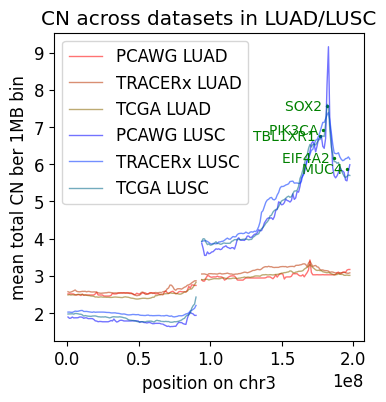

In [45]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
fig, ax = fig_lines(means_single, labels, column="total_cn", color=["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"],  chrom="chr3")
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]:
        mid = calc_mid(row)
        plt.scatter(mid, row['total_cn'], color='green', s=2)
        offset = 0
        text = f"{row['name']} "
        plt.text(mid, row['total_cn'] + offset, text, color="green", size=10, ha='right', va='center')

save_cns_fig(f"fig_COSMIC_IG_att_{chrom}")
save_cns_fig(f"fig_COSMIC_lines_IG_att_chr3")

# TCGA profiles

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per segment'>)

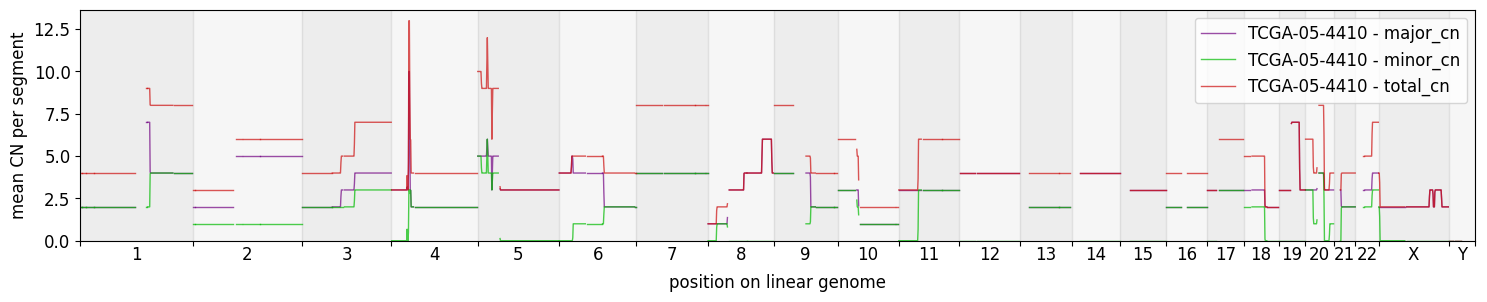

In [46]:
tcga_sel_ids = list(samples_df.query("source == 'TCGA_hg19' and type == 'LUAD'").index[8:9])

groups = []
for id in tcga_sel_ids:
	select_cns = cns_df.set_index("sample_id").loc[id].reset_index()
	groups.append(add_total_cn(select_cns))

names = [name for name in tcga_sel_ids]
fig_lines(groups, names)

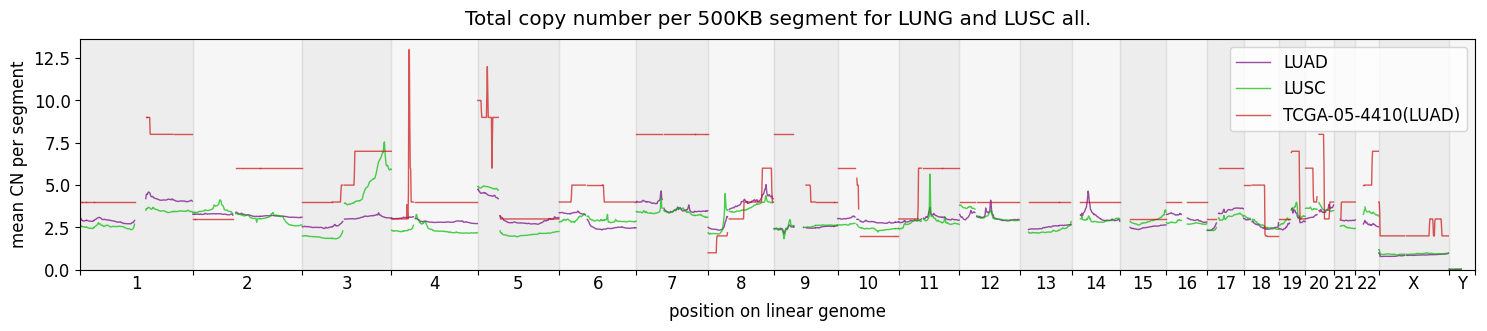

In [47]:
fig, ax = fig_lines(means_all + [ groups[-1] ], ["LUAD", "LUSC", tcga_sel_ids[0] + "(LUAD)"], column="total_cn")
ax.set_title("Total copy number per 500KB segment for LUNG and LUSC all.", pad=10)
plt.savefig(f"{img_path}/fig_LUAD_LUSC_all.pdf", bbox_inches='tight')
plt.savefig(f"{img_path}/fig_LUAD_LUSC_all.png", bbox_inches='tight', dpi=300)

(0.0, 16.0)

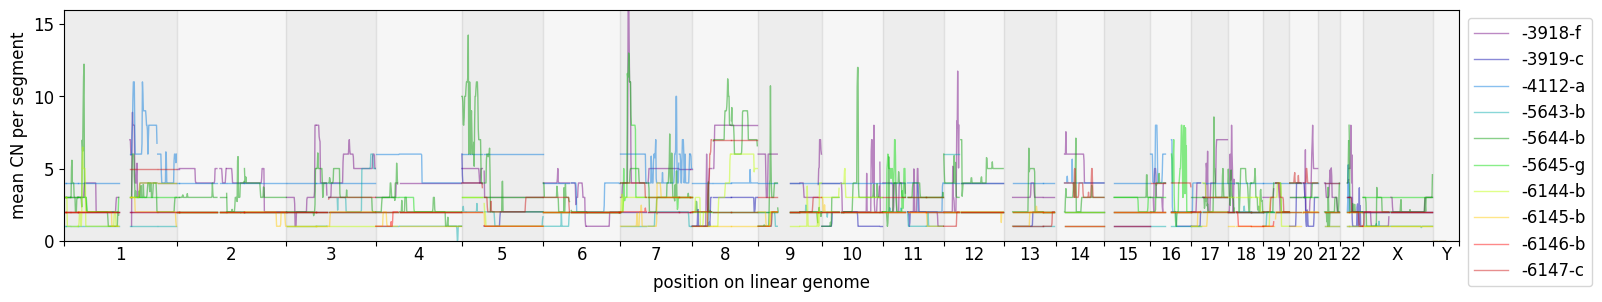

In [48]:
tcga_sel_ids = list(samples_df.query("source == 'TCGA_hg19' and type == 'LUAD'").index[50:60])

groups = []
for id in tcga_sel_ids:
	select_cns = cns_df.set_index("sample_id").loc[id].reset_index()
	groups.append(add_total_cn(select_cns))

names = [name[-7:] for name in tcga_sel_ids]
fig, ax = fig_lines(groups, names, column="total_cn")
ax.set_ylim(0,16)